# Ensemble of contracts -- spreading the hedge across DTE/moneyness slots

Self-contained (own data load, own formulas -- nothing imported from `deprecated/` or any
other notebook).

**The hypothesis**: `combined_strategy_sandbox.ipynb` concentrates the entire hedge into
ONE contract at a time (one moneyness bucket, one DTE). That single contract's
idiosyncratic behavior (a stale print, a liquidity gap, a specific expiry's decay path)
drives the whole hedge's outcome. Spreading the same total target dollar-delta across
several contracts with different DTEs and moneyness might smooth the path -- lower
drawdown -- without giving up much of the underlying edge (20% OTM has now been
confirmed twice as the strongest moneyness).

**Design**: three equally-weighted slots (1/3 of target dollar-delta each), each with
its own frozen (bucket, target_dte, roll_dte) -- a real spread across both dimensions,
not just one:

| Slot | Bucket | Target DTE | Roll DTE |
|---|---|---|---|
| 1 | 10% OTM | 60 | 14 |
| 2 | 20% OTM | 90 | 14 |
| 3 | 20% OTM | 150 | 21 |

Slot 2 matches `combined_strategy_sandbox.ipynb`'s validated winner exactly (a "core"
allocation); slots 1 and 3 spread shorter/less-OTM and longer/further-OTM around it.

**Mechanics, extending what's already validated rather than inventing something new**:
- Each slot rolls independently on its OWN DTE trigger, sized to 1/3 of the static
  notional target (same convention as every other notebook's DTE-forced roll).
- A single PORTFOLIO-level coverage-band check (10% band, matching Lever 3) sums all
  three slots' current dollar-delta; if the total drifts outside the band, ALL slots
  reroll together, each re-sized to 1/3 of the short leg's current actual dollar-delta
  (same band-correction sizing convention as `combined_strategy_sandbox.ipynb`).
- Each slot independently uses Lever 1's `cost_benefit` rule (price both TSLA and TSLL
  at that slot's bucket/DTE, buy whichever is cheaper).

Compared against the single-position 20%-OTM/90-DTE baseline on the same three periods:
testA, testB, and the continuous out-of-train run (established as the more realistic risk
measure in `combined_strategy_sandbox.ipynb`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
DATA = ROOT / "data"
%matplotlib inline

## Load data (fresh parse, same conventions as `00_foundation_sandbox.ipynb`)

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index().dropna()

tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index().dropna()

tsla_calls = pd.read_parquet(DATA / "processed" / "TSLA_calls_close.parquet")
tsll_calls = pd.read_parquet(DATA / "processed" / "TSLL_calls_close.parquet")

r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()
dates = r_tsla.index.intersection(r_tsll.index)
r_tsla, r_tsll = r_tsla.loc[dates], r_tsll.loc[dates]
tsla_spot, tsll_spot = tsla_spot.loc[dates], tsll_spot.loc[dates]

print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

960 trading days, 2022-08-10 -> 2026-06-08


## Pre-indexed lookups (performance only)

In [3]:
tsla_calls_by_date = {d: g for d, g in tsla_calls.groupby("date")}
tsll_calls_by_date = {d: g for d, g in tsll_calls.groupby("date")}

tsla_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsla_calls.itertuples(index=False)}
tsll_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsll_calls.itertuples(index=False)}

## Fresh formulas -- Black-Scholes delta, rolling vol/beta, contract selection, sizing, risk metrics

In [4]:
R_RF = 0.05
ESTIMATION_WINDOW = 21

MONEYNESS_RANGES = {
    "ATM": (0.95, 1.05),
    "10% OTM": (1.05, 1.15),
    "20% OTM": (1.15, 1.25),
}


def bs_call_delta(S, K, T_years, r, sigma):
    """Black-Scholes European call delta = N(d1). Clipped to [0.01, 1.0]."""
    if T_years <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 1.0 if S > K else 0.01
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T_years) / (sigma * np.sqrt(T_years))
    return float(np.clip(norm.cdf(d1), 0.01, 1.0))


tsla_sigma = (r_tsla.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
tsll_sigma = (r_tsll.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
beta_tsll_vs_tsla = ((r_tsll.rolling(ESTIMATION_WINDOW).cov(r_tsla)
                      / r_tsla.rolling(ESTIMATION_WINDOW).var()).shift(1)).ffill().bfill()

assert tsla_sigma.isna().sum() == 0 and tsll_sigma.isna().sum() == 0 and beta_tsll_vs_tsla.isna().sum() == 0


def select_contract(calls_by_date, spot_series, date, moneyness_bucket, target_dte, max_dte):
    """Filter to the moneyness bucket, require a real fill, positive DTE within max_dte,
    pick the contract closest to target_dte. Moneyness is ALWAYS bounded."""
    day = calls_by_date.get(date)
    if day is None or day.empty:
        return None
    lo, hi = MONEYNESS_RANGES[moneyness_bucket]
    s = float(spot_series.loc[date])
    moneyness = day["strike"] / s
    dte = (day["expiry"] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask]
    if candidates.empty:
        return None
    dte_c = (candidates["expiry"] - date).dt.days
    idx = (dte_c - target_dte).abs().idxmin()
    return candidates.loc[idx]


def size_position(row, spot_val, sigma_val, target_dollar_delta, date):
    """Delta-neutral contract count for a given target dollar-delta. CONTRACTS, not
    shares -- cost is always n_contracts * 100 * entry_price."""
    if row is None:
        return 0.0, float("inf"), 0.0
    entry = float(row["px_last"])
    T = max((row["expiry"] - date).days / 365.25, 1 / 365)
    delta = bs_call_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
    n_contracts = target_dollar_delta / (max(delta, 0.01) * 100 * spot_val)
    cost = n_contracts * 100 * entry
    return n_contracts, cost, entry


def cagr(equity):
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    end = equity.iloc[-1]
    return -1.0 if end <= 0 else end ** (1 / n_years) - 1


def sharpe(returns, rf=0.0):
    excess = returns - rf / 252
    vol = excess.std()
    return float("nan") if vol == 0 else excess.mean() / vol * np.sqrt(252)


def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

## Ensemble slots and the shared coverage band

In [5]:
ENSEMBLE_SLOTS = [
    {"bucket": "10% OTM", "target_dte": 60, "roll_dte": 14},
    {"bucket": "20% OTM", "target_dte": 90, "roll_dte": 14},   # matches the single-position winner
    {"bucket": "20% OTM", "target_dte": 150, "roll_dte": 21},
]
N_SLOTS = len(ENSEMBLE_SLOTS)
BAND_WIDTH = 0.10   # same as Lever 3 / combined_strategy

print(f"{N_SLOTS} slots, each allocated 1/{N_SLOTS} of target dollar-delta:")
for i, s in enumerate(ENSEMBLE_SLOTS):
    print(f"  slot {i}: {s['bucket']}, target_dte={s['target_dte']}, roll_dte={s['roll_dte']}")

3 slots, each allocated 1/3 of target dollar-delta:
  slot 0: 10% OTM, target_dte=60, roll_dte=14
  slot 1: 20% OTM, target_dte=90, roll_dte=14
  slot 2: 20% OTM, target_dte=150, roll_dte=21


## Simulation -- N concurrent positions, independent DTE rolls, shared portfolio-level coverage band

In [6]:
def simulate_ensemble(sim_dates, notional=1.0):
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    positions = [None] * N_SLOTS   # each: underlying, raw_id, strike, expiry, n, price
    S_prev = S_incep
    stats = {"dte_rolls": 0, "band_corrections": 0, "fills_tsla": 0, "fills_tsll": 0, "misses": 0}

    equity = pd.Series(index=sim_dates, dtype=float)
    coverage_history = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else tsll_price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        if px is None or pd.isna(px):
            return pos["price"]
        return float(px)

    def current_delta(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        sigma_series = tsla_sigma if pos["underlying"] == "tsla" else tsll_sigma
        S_pos = float(spot_series.loc[date])
        T = max((pos["expiry"] - date).days / 365.25, 1 / 365)
        return bs_call_delta(S_pos, pos["strike"], T, R_RF, float(sigma_series.loc[date])), S_pos

    def open_slot(slot_idx, date, target_dollar_delta):
        """cost_benefit: price both TSLA and TSLL at this slot's bucket/DTE, buy cheaper."""
        slot = ENSEMBLE_SLOTS[slot_idx]
        bucket, target_dte = slot["bucket"], slot["target_dte"]
        max_dte = target_dte + 20
        beta_t = float(beta_tsll_vs_tsla.loc[date])
        tdd_tsla = beta_t * target_dollar_delta
        tdd_tsll = target_dollar_delta

        row_tsla = select_contract(tsla_calls_by_date, tsla_spot, date, bucket, target_dte, max_dte)
        row_tsll = select_contract(tsll_calls_by_date, tsll_spot, date, bucket, target_dte, max_dte)
        n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[date]), float(tsla_sigma.loc[date]), tdd_tsla, date)
        n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[date]), float(tsll_sigma.loc[date]), tdd_tsll, date)

        chosen = None
        if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
            chosen = "tsla"
        elif row_tsll is not None:
            chosen = "tsll"

        if chosen == "tsla":
            stats["fills_tsla"] += 1
            return {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                    "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
        elif chosen == "tsll":
            stats["fills_tsll"] += 1
            return {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                    "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
        else:
            stats["misses"] += 1
            return None

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today
        current_short_dd = n_shares * S_today

        # --- mark every held slot ---
        for pos in positions:
            if pos is not None:
                px = mtm(pos, d)
                option_pnl += pos["n"] * 100 * (px - pos["price"])
                pos["price"] = px

        # --- portfolio-level coverage ---
        current_hedge_dd = 0.0
        for pos in positions:
            if pos is not None:
                delta_now, S_pos_now = current_delta(pos, d)
                current_hedge_dd += pos["n"] * 100 * delta_now * S_pos_now
        coverage_ratio = current_hedge_dd / current_short_dd if current_short_dd > 0 else 1.0
        coverage_history.loc[d] = coverage_ratio

        # --- each slot's own DTE-forced roll check ---
        any_forced = False
        for i, pos in enumerate(positions):
            held_dte = (pos["expiry"] - d).days if pos is not None else -1
            forced = pos is None or held_dte < ENSEMBLE_SLOTS[i]["roll_dte"]
            if forced:
                any_forced = True
                if pos is not None:
                    stats["dte_rolls"] += 1
                positions[i] = open_slot(i, d, notional / N_SLOTS)

        # --- portfolio-level band correction (only if nothing was already forced this day) ---
        if not any_forced and (coverage_ratio < (1 - BAND_WIDTH) or coverage_ratio > (1 + BAND_WIDTH)):
            stats["band_corrections"] += 1
            per_slot_target = current_short_dd / N_SLOTS
            for i in range(N_SLOTS):
                positions[i] = open_slot(i, d, per_slot_target)

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity, stats, coverage_history

## Single-position baseline (for comparison -- same as `combined_strategy_sandbox.ipynb`)

In [7]:
BASELINE_BUCKET, BASELINE_DTE, BASELINE_ROLL = "20% OTM", 90, 14


def simulate_single(sim_dates, notional=1.0):
    max_dte = BASELINE_DTE + 20
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    S_prev = S_incep

    equity = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else tsll_price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        if px is None or pd.isna(px):
            return pos["price"]
        return float(px)

    def current_delta(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        sigma_series = tsla_sigma if pos["underlying"] == "tsla" else tsll_sigma
        S_pos = float(spot_series.loc[date])
        T = max((pos["expiry"] - date).days / 365.25, 1 / 365)
        return bs_call_delta(S_pos, pos["strike"], T, R_RF, float(sigma_series.loc[date])), S_pos

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        current_short_dd = n_shares * S_today
        held_dte = (position["expiry"] - d).days if position is not None else -1
        forced_roll = position is None or held_dte < BASELINE_ROLL

        band_triggered = False
        if position is not None:
            delta_now, S_pos_now = current_delta(position, d)
            current_hedge_dd = position["n"] * 100 * delta_now * S_pos_now
            coverage_ratio = current_hedge_dd / current_short_dd if current_short_dd > 0 else 1.0
            if not forced_roll and (coverage_ratio < (1 - BAND_WIDTH) or coverage_ratio > (1 + BAND_WIDTH)):
                band_triggered = True

        if forced_roll or band_triggered:
            beta_t = float(beta_tsll_vs_tsla.loc[d])
            base_dd = notional if forced_roll else current_short_dd
            tdd_tsla = beta_t * base_dd
            tdd_tsll = base_dd

            row_tsla = select_contract(tsla_calls_by_date, tsla_spot, d, BASELINE_BUCKET, BASELINE_DTE, max_dte)
            row_tsll = select_contract(tsll_calls_by_date, tsll_spot, d, BASELINE_BUCKET, BASELINE_DTE, max_dte)
            n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[d]), float(tsla_sigma.loc[d]), tdd_tsla, d)
            n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[d]), float(tsll_sigma.loc[d]), tdd_tsll, d)

            chosen = None
            if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
                chosen = "tsla"
            elif row_tsll is not None:
                chosen = "tsll"

            if chosen == "tsla":
                position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                            "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
            elif chosen == "tsll":
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
            else:
                position = None

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity

## Windows -- same as `combined_strategy_sandbox.ipynb`, including the continuous out-of-train run

In [8]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")
TEST_A_END = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")
TEST_B_END = pd.Timestamp("2025-12-16")

train_dates = dates[(dates >= TRAIN_START) & (dates <= TRAIN_END)]
test_a_dates = dates[(dates >= TEST_A_START) & (dates <= TEST_A_END)]
test_b_dates = dates[(dates >= TEST_B_START) & (dates <= TEST_B_END)]
out_of_train_dates = dates[dates > TRAIN_END]

WINDOWS = {"train": train_dates, "testA": test_a_dates, "testB": test_b_dates, "out_of_train": out_of_train_dates}
for name, d in WINDOWS.items():
    print(f"{name}: {len(d)} days, {d.min().date()} -> {d.max().date()}")

train: 80 days, 2022-09-09 -> 2023-01-03
testA: 76 days, 2024-12-17 -> 2025-04-08
testB: 175 days, 2025-04-08 -> 2025-12-16
out_of_train: 859 days, 2023-01-04 -> 2026-06-08


## Run both -- ensemble vs. single-position baseline -- on all four windows

In [9]:
rows = []
curves = {}
for win_name, win_dates in WINDOWS.items():
    eq_ens, stats_ens, cov_ens = simulate_ensemble(win_dates)
    eq_single = simulate_single(win_dates)
    curves[win_name] = {"ensemble": eq_ens, "single": eq_single, "coverage": cov_ens}

    rows.append({"strategy": "ensemble", "window": win_name,
                 "sharpe": sharpe(eq_ens.pct_change().dropna()), "cagr": cagr(eq_ens), "maxdd": max_drawdown(eq_ens),
                 "dte_rolls": stats_ens["dte_rolls"], "band_corrections": stats_ens["band_corrections"],
                 "misses": stats_ens["misses"]})
    rows.append({"strategy": "single (baseline)", "window": win_name,
                 "sharpe": sharpe(eq_single.pct_change().dropna()), "cagr": cagr(eq_single), "maxdd": max_drawdown(eq_single),
                 "dte_rolls": np.nan, "band_corrections": np.nan, "misses": np.nan})

comparison = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
comparison.pivot(index="window", columns="strategy", values=["sharpe", "cagr", "maxdd"])

sharpe                        cagr                       maxdd                  
strategy      ensemble single (baseline)  ensemble single (baseline)  ensemble single (baseline)
window                                                                                          
out_of_train  0.957979          0.862870  0.448815          0.452569 -0.444328         -0.441496
testA         1.949121          1.815563  0.584372          0.806808 -0.082873         -0.114230
testB        -0.027250          0.513577 -0.409023          0.032488 -0.626439         -0.572582
train         1.173890          3.041709  0.359543          1.875190 -0.088920         -0.081932

## Equity curves -- ensemble vs. single, per window

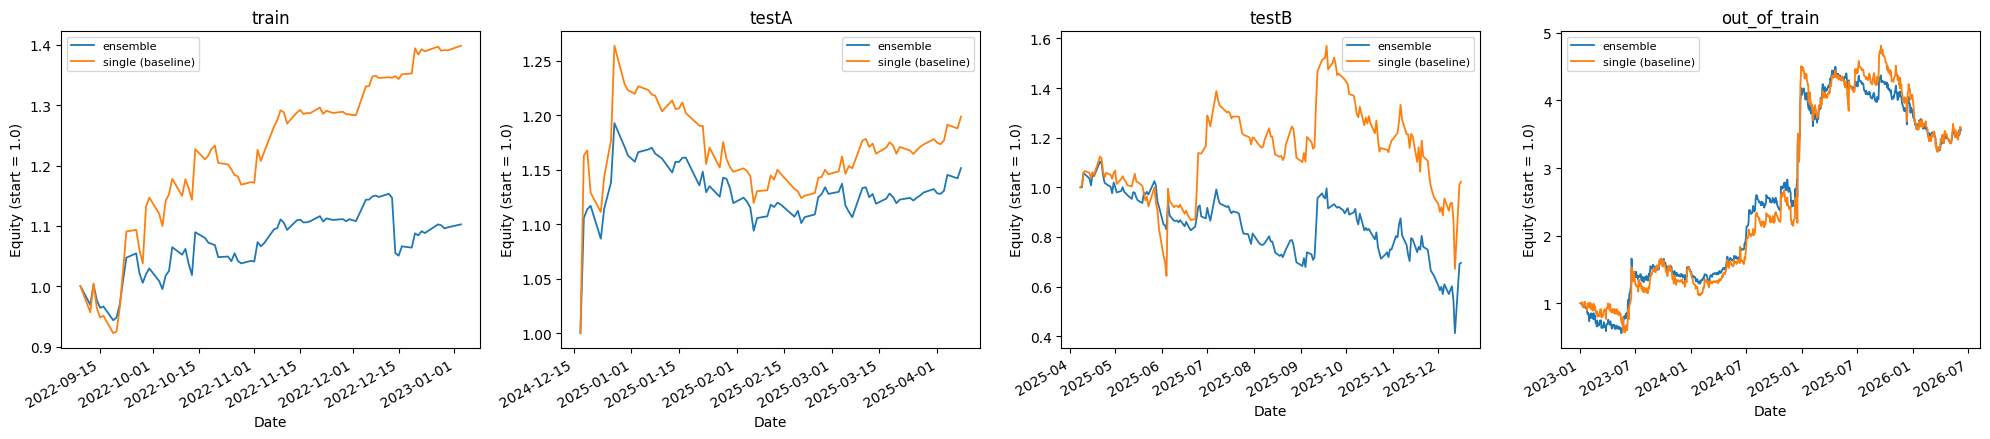

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, win_name in zip(axes, WINDOWS.keys()):
    curves[win_name]["ensemble"].plot(ax=ax, label="ensemble", linewidth=1.3)
    curves[win_name]["single"].plot(ax=ax, label="single (baseline)", linewidth=1.3)
    ax.set_title(win_name)
    ax.set_ylabel("Equity (start = 1.0)")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Sanity checks

In [11]:
for win_name, c in curves.items():
    assert c["ensemble"].isna().sum() == 0, f"{win_name}: ensemble equity has NaNs"
    assert c["single"].isna().sum() == 0, f"{win_name}: single equity has NaNs"
    valid_cov = c["coverage"].dropna()
    if len(valid_cov) > 0:
        assert (valid_cov > -0.01).all() and (valid_cov < 50).all(), f"{win_name}: absurd ensemble coverage ratio"

print("Ensemble sanity checks passed.")
print("\nFinal comparison:")
print(comparison.pivot(index="window", columns="strategy", values=["sharpe", "cagr", "maxdd"]).to_string())

Ensemble sanity checks passed.

Final comparison:
                sharpe                        cagr                       maxdd                  
strategy      ensemble single (baseline)  ensemble single (baseline)  ensemble single (baseline)
window                                                                                          
out_of_train  0.957979          0.862870  0.448815          0.452569 -0.444328         -0.441496
testA         1.949121          1.815563  0.584372          0.806808 -0.082873         -0.114230
testB        -0.027250          0.513577 -0.409023          0.032488 -0.626439         -0.572582
train         1.173890          3.041709  0.359543          1.875190 -0.088920         -0.081932
